# Estabilidade

Neste notebook vamos estudar técnicas que tornam o treinamento de redes neurais mais **estável** e eficiente.  
O objetivo é entender como escolhas de **normalização, inicialização de parâmetros, dropout e ajuste dinâmico da taxa de aprendizado** afetam a convergência e o desempenho do modelo.

Esses elementos ajudam a evitar problemas clássicos como **gradientes explosivos/vanishing**, **treinamento instável** e **convergência lenta**.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
from tqdm import tqdm
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
device = torch.device(
    'cuda' if torch.cuda.is_available() # GPU
    else 'mps' if torch.backends.mps.is_available() # MPS (Mac Silicon)
    else 'cpu' # CPU
)
print(f"Usando o dispositivo: {device}")

Usando o dispositivo: mps


## Normalização

A normalização é uma técnica fundamental em redes neurais para acelerar e estabilizar o treinamento. A ideia é controlar a escala e a distribuição dos dados, seja na entrada da rede ou entre camadas, reduzindo problemas de gradientes desbalanceados e acelerando a convergência.

### Input Normalization

Antes do treinamento, normalizamos os dados de entrada $x$ para que apresentem **média próxima de zero** e **desvio padrão próximo de um**:

$$
x' = \frac{x - \mu}{\sigma}
$$

- $\mu$: média global do dataset  
- $\sigma$: desvio padrão global  

Isso garante que todas as features estejam em escalas comparáveis.  
Vamos calcular $\mu$ e $\sigma$ para o dataset **MNIST**, que contém imagens em tons de cinza de dígitos manuscritos, e em seguida podemos aplicar a normalização diretamente durante o carregamento dos dados usando `transforms.Normalize`.

In [3]:
import torchvision
import torchvision.transforms as transforms

# Carregar dataset apenas como Tensor
dataset_tmp = torchvision.datasets.MNIST(
    root="./data", train=True, download=True,
    transform=transforms.ToTensor()
)

# Concatenar todos os dados em um tensor [N,1,28,28]
loader_tmp = torch.utils.data.DataLoader(dataset_tmp, batch_size=len(dataset_tmp), shuffle=False)
data_tmp = next(iter(loader_tmp))[0]  # só imagens
print("Shape:", data_tmp.shape)   # [60000, 1, 28, 28]

# Calcular mean e std por canal
mean = data_tmp.mean().item()
std = data_tmp.std().item()
print(f"Mean: {mean:.4f}, Std: {std:.4f}")

Shape: torch.Size([60000, 1, 28, 28])
Mean: 0.1307, Std: 0.3081


In [4]:
from torch.utils.data import DataLoader, Subset

# Transformação
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Datasets
train_data = torchvision.datasets.MNIST("./data", train=True, download=True, transform=transform)
test_data  = torchvision.datasets.MNIST("./data", train=False, download=True, transform=transform)

# Subsets menores
train_subset = Subset(train_data, torch.randperm(len(train_data))[:4000])
val_subset   = Subset(test_data,  torch.randperm(len(test_data))[:1000])

# DataLoaders
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_subset, batch_size=64)

print(len(train_subset), len(val_subset))

4000 1000


### Batch Normalization

Mesmo após normalizar a entrada, as ativações internas podem mudar de escala durante o treinamento, fenômeno conhecido como **internal covariate shift**.  

A **Batch Normalization** resolve esse problema ao normalizar as ativações em cada mini-batch:

$$
\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \quad 
y_i = \gamma \hat{x}_i + \beta
$$

- $\mu_B, \sigma_B^2$: média e variância do mini-batch  
- $\epsilon$: termo de estabilidade numérica  
- $\gamma, \beta$: parâmetros treináveis que permitem restaurar escala e deslocamento  

Com isso, o treinamento torna-se mais estável, permite taxas de aprendizado maiores e pode acelerar a convergência.

In [5]:
# Exemplo de uso de Batch Normalization para vetores de dimensão 128
batch_norm = nn.BatchNorm1d(128)

# Batch fictício com 32 amostras de dimensão 128
x = torch.randn(32, 128)

# Aplicar BatchNorm
y = batch_norm(x)
print("Input shape:", x.shape)
print("Output shape:", y.shape)

Input shape: torch.Size([32, 128])
Output shape: torch.Size([32, 128])


## Inicialização de Parâmetros

A escolha da inicialização dos pesos influencia diretamente a propagação dos sinais pela rede e a velocidade de convergência do treinamento.  
Se os pesos começarem com valores muito grandes, os gradientes podem explodir; se forem muito pequenos, os gradientes podem desaparecer.  

O objetivo das estratégias modernas de inicialização é manter a **variância dos sinais e dos gradientes estável** através das camadas da rede.

### Inicializações Simples

- **Zeros**: todos os pesos inicializados como zero. Não é recomendada, pois elimina a simetria entre neurônios, impedindo o aprendizado.  
- **Uniforme Aleatória**: pesos amostrados de uma distribuição uniforme $U(a,b)$. Pode funcionar em redes rasas, mas em redes profundas tende a causar instabilidade de gradientes.  

### Xavier Initialization

Proposta por Glorot & Bengio (2010), a ideia é ajustar a variância dos pesos para manter o mesmo nível de variância entre a entrada e a saída de cada camada linear.  

$$
Var[w] = \frac{2}{n_{in} + n_{out}}
$$

- $n_{in}$: número de entradas da camada  
- $n_{out}$: número de saídas da camada  

Com isso, evita-se tanto a saturação das ativações quanto a explosão/decadência dos gradientes em redes profundas.

### He Initialization

Proposta por He et al. (2015), é uma variação da Xavier específica para funções de ativação ReLU e suas variantes.  
A ideia é considerar que metade das ativações da ReLU são zeradas, exigindo maior variância inicial:  

$$
Var[w] = \frac{2}{n_{in}}
$$

- $n_{in}$: número de entradas da camada  

Essa inicialização é o padrão em muitas arquiteturas modernas com ReLU.

In [6]:
def plot_weight_distribution(model, bins=50, title=""):
    plt.figure(figsize=(10, 5))
    for i, m in enumerate(model):
        if isinstance(m, nn.Linear):
            weights = m.weight.detach().cpu().numpy().flatten()
            plt.hist(weights, bins=bins, alpha=0.5, label=f'Layer {i} ({m.out_features} units)')
    plt.title(f"Distribuição dos Pesos - {title}")
    plt.xlabel("Valor do Peso")
    plt.ylabel("Frequência")
    plt.legend()
    plt.show()

In [7]:
import torch.nn.init as init

# Exemplo de inicialização em um modelo com várias camadas
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

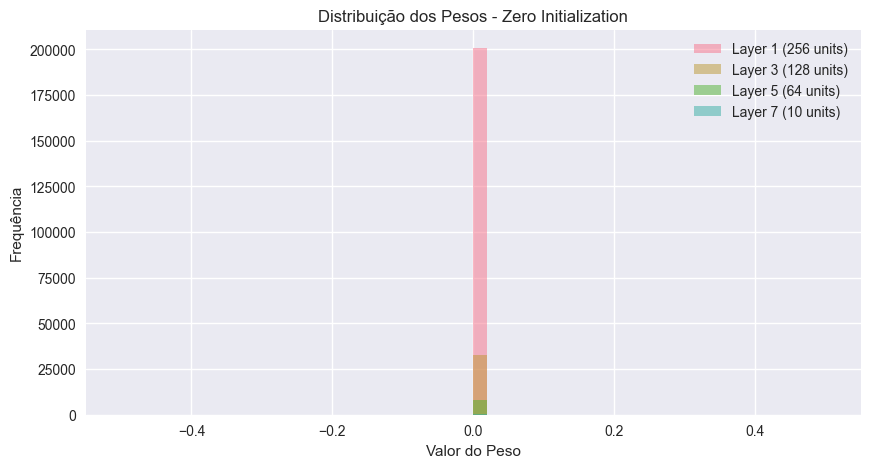

In [8]:
# Inicialização zero
for layer in model:
    if isinstance(layer, nn.Linear):
        init.zeros_(layer.weight)
        init.zeros_(layer.bias)

plot_weight_distribution(model, title="Zero Initialization")

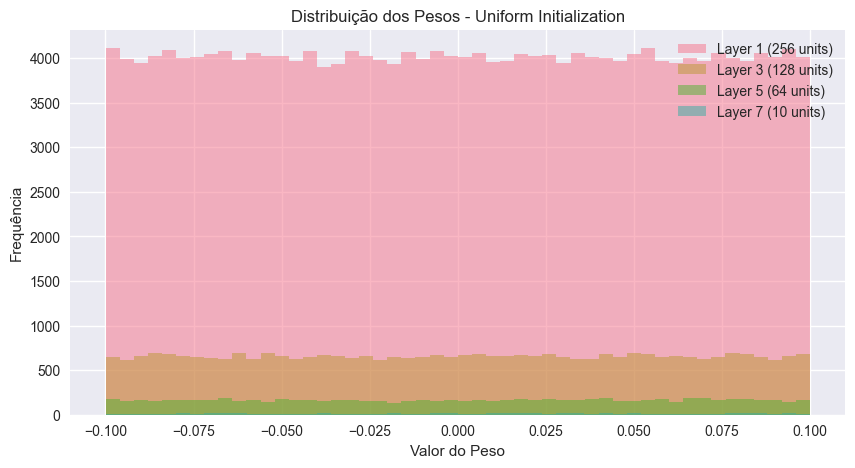

In [9]:
# Inicialização uniforme
for layer in model:
    if isinstance(layer, nn.Linear):
        init.uniform_(layer.weight, a=-0.1, b=0.1)
        init.zeros_(layer.bias)

plot_weight_distribution(model, title="Uniform Initialization")

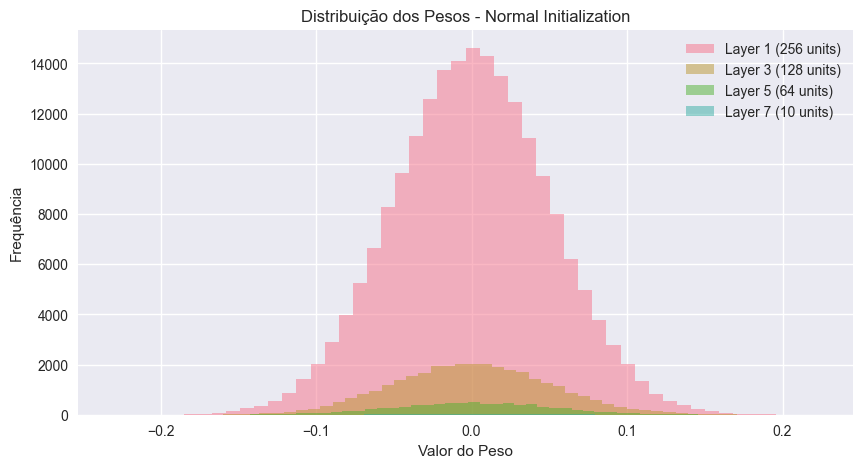

In [10]:
# Inicialização normal
for layer in model:
    if isinstance(layer, nn.Linear):
        init.normal_(layer.weight, mean=0.0, std=0.05)
        init.zeros_(layer.bias)

plot_weight_distribution(model, title="Normal Initialization")

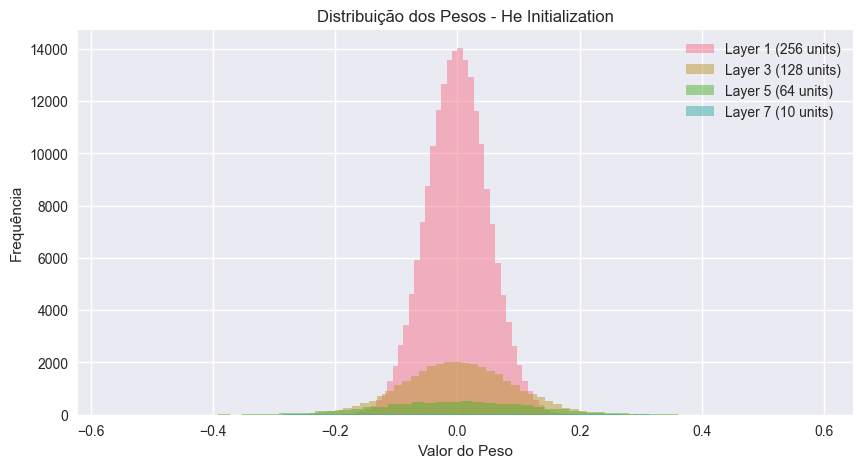

In [11]:
# Inicialização He
for layer in model:
    if isinstance(layer, nn.Linear):
        init.kaiming_normal_(layer.weight, nonlinearity="relu")
        init.zeros_(layer.bias)

plot_weight_distribution(model, title="He Initialization")

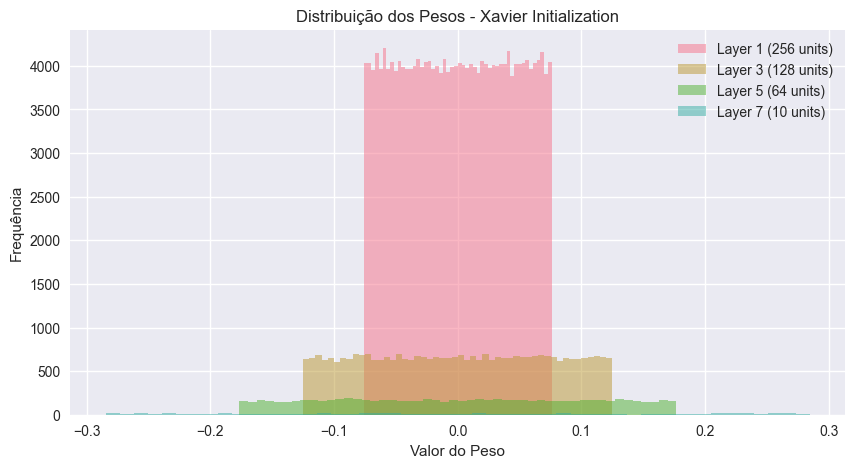

In [12]:
# Inicialização Xavier
for layer in model:
    if isinstance(layer, nn.Linear):
        init.xavier_uniform_(layer.weight)
        init.zeros_(layer.bias)

plot_weight_distribution(model, title="Xavier Initialization")

## Decaimento da Taxa de Aprendizado

A **taxa de aprendizado** ($\eta$) controla o tamanho dos passos do otimizador.  
Se $\eta$ for muito alta, o treinamento pode divergir; se for muito baixa, pode ser lento.  
Uma estratégia comum é aplicar **decaimento da taxa de aprendizado**, ajustando gradualmente $\eta$ ao longo do treinamento:

- **Step Decay**: reduz $\eta$ em etapas fixas, após um número pré-definido de épocas  

$$
\eta_t = \eta_0 \cdot \gamma^{\lfloor t / s \rfloor}
$$

- **Exponential Decay**: reduz $\eta$ de forma suave e contínua  

$$
\eta_t = \eta_0 \cdot \gamma^t
$$

- **Reduce on Plateau**: monitora uma métrica (ex.: loss de validação) e reduz $\eta$ quando não há melhora por certo número de épocas  

$$
\eta_{t+1} = \eta_t \cdot \gamma \quad \text{se não houver melhora por $p$ épocas}
$$

Epoch 1/15, Loss = 1.7894, LR = 0.50000
Epoch 2/15, Loss = 1.2999, LR = 0.50000
Epoch 3/15, Loss = 1.0900, LR = 0.50000
Epoch 4/15, Loss = 0.8951, LR = 0.50000
Epoch 5/15, Loss = 0.7603, LR = 0.50000
Epoch 6/15, Loss = 0.5216, LR = 0.05000
Epoch 7/15, Loss = 0.4574, LR = 0.05000
Epoch 8/15, Loss = 0.4377, LR = 0.05000
Epoch 9/15, Loss = 0.4204, LR = 0.05000
Epoch 10/15, Loss = 0.4067, LR = 0.05000
Epoch 11/15, Loss = 0.3907, LR = 0.00500
Epoch 12/15, Loss = 0.3879, LR = 0.00500
Epoch 13/15, Loss = 0.3865, LR = 0.00500
Epoch 14/15, Loss = 0.3840, LR = 0.00500
Epoch 15/15, Loss = 0.3845, LR = 0.00500


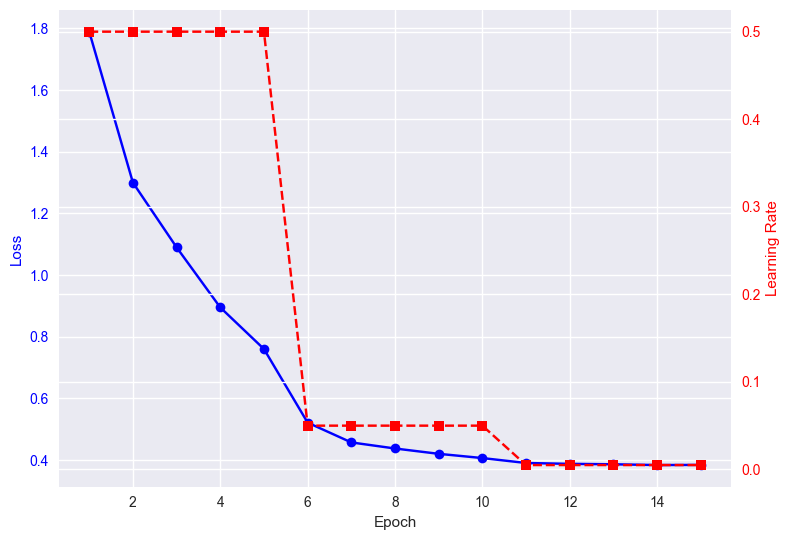

In [13]:
from torch.optim.lr_scheduler import StepLR, ExponentialLR, ReduceLROnPlateau

# Modelo simples
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 32),
    nn.ReLU(),
    nn.Linear(32, 10)
).to(device)

# Otimizador e scheduler
optimizer = optim.SGD(model.parameters(), lr=0.5)

scheduler = StepLR(optimizer, step_size=5, gamma=0.1)
# scheduler = ExponentialLR(optimizer, gamma=0.9)
# scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, threshold=0.5)

criterion = nn.CrossEntropyLoss()

# Treinamento simples em MNIST
n_epochs = 15
train_losses = []
lrs = []

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)
    lrs.append(optimizer.param_groups[0]['lr'])
    scheduler.step()
    print(f"Epoch {epoch+1}/{n_epochs}, Loss = {epoch_loss:.4f}, LR = {lrs[-1]:.5f}")

# Plot Loss e LR
fig, ax1 = plt.subplots()
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss", color="blue")
ax1.plot(range(1, n_epochs+1), train_losses, marker="o", color="blue", label="Train Loss")
ax1.tick_params(axis="y", labelcolor="blue")
ax2 = ax1.twinx()
ax2.set_ylabel("Learning Rate", color="red")
ax2.plot(range(1, n_epochs+1), lrs, marker="s", linestyle="--", color="red", label="LR")
ax2.tick_params(axis="y", labelcolor="red")
fig.tight_layout()
plt.show()

## Gradient Clipping

Em algumas redes, especialmente mais profundas ou recorrentes, os gradientes podem crescer demais durante o backpropagation.  
Quando isso acontece, as atualizações dos pesos ficam muito grandes, o treinamento pode oscilar fortemente e até divergir.

O **gradient clipping** é uma técnica simples para limitar esse crescimento.  
A ideia é restringir a magnitude do gradiente antes de atualizar os parâmetros do modelo.

Existem duas formas comuns:

- Clip por valor: limita cada componente do gradiente individualmente a um intervalo fixo  
- Clip por norma: limita a norma total do vetor de gradientes  

A forma mais usada é o clip por norma:

$$
g \leftarrow g \cdot \min\left(1, \frac{\tau}{\|g\|}\right)
$$

- $g$: vetor de gradientes  
- $\|g\|$: norma do gradiente  
- $\tau$: valor máximo permitido  

Se a norma do gradiente já for menor que $\tau$, nada muda.  
Se for maior, o gradiente é reescalado para ficar no limite.

Isso ajuda a evitar gradientes explosivos e torna o treinamento mais estável.

In [14]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
).to(device)

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Epoch 1/5, Loss = 0.9404
Epoch 2/5, Loss = 0.3673
Epoch 3/5, Loss = 0.2679
Epoch 4/5, Loss = 0.2170
Epoch 5/5, Loss = 0.1712


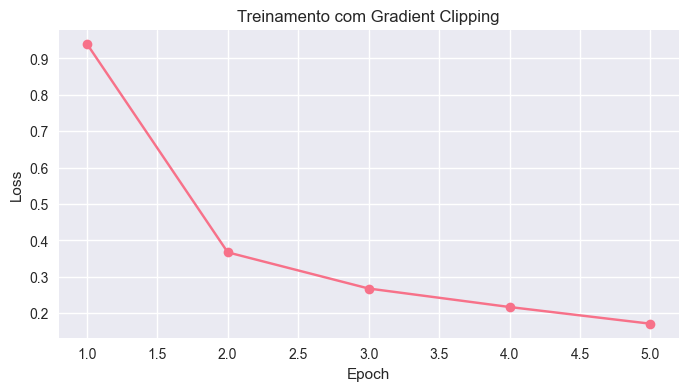

In [16]:
n_epochs = 5
train_losses = []

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()

        # Gradient clipping (por norma)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        # Gradient clipping (por valor)
        # torch.nn.utils.clip_grad_value_(model.parameters(), clip_value=0.5)

        optimizer.step()
        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{n_epochs}, Loss = {epoch_loss:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, n_epochs + 1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Treinamento com Gradient Clipping")
plt.grid(True)
plt.show()

## Treinamento Completo

Agora vamos juntar várias técnicas vistas ao longo do notebook em um único exemplo de treinamento:

- **Batch Normalization** para estabilizar as ativações internas  
- **Inicialização He** para camadas com ReLU  
- **Scheduler** para ajustar dinamicamente a taxa de aprendizado  
- **Gradient Clipping** para evitar gradientes explosivos  

A ideia é mostrar um pipeline mais completo e próximo do que normalmente usamos na prática.

In [17]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            
            nn.Linear(64, 10)
        )
        
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

In [18]:
model = MLP().to(device)
print(model)

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [20]:
n_epochs = 15

train_losses = []
val_losses = []
train_accs = []
val_accs = []
lrs = []

for epoch in range(n_epochs):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss += loss.item()
        preds = outputs.argmax(dim=1)
        train_correct += (preds == y).sum().item()
        train_total += y.size(0)

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)

            outputs = model(X)
            loss = criterion(outputs, y)

            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            val_correct += (preds == y).sum().item()
            val_total += y.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    lrs.append(optimizer.param_groups[0]["lr"])

    print(
        f"Epoch {epoch+1}/{n_epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.6f}"
    )

    scheduler.step()

Epoch 1/15 | Train Loss: 0.7973 | Train Acc: 0.7875 | Val Loss: 0.3375 | Val Acc: 0.9130 | LR: 0.001000
Epoch 2/15 | Train Loss: 0.2581 | Train Acc: 0.9370 | Val Loss: 0.2393 | Val Acc: 0.9340 | LR: 0.001000
Epoch 3/15 | Train Loss: 0.1373 | Train Acc: 0.9768 | Val Loss: 0.1976 | Val Acc: 0.9470 | LR: 0.001000
Epoch 4/15 | Train Loss: 0.0784 | Train Acc: 0.9885 | Val Loss: 0.1935 | Val Acc: 0.9450 | LR: 0.001000
Epoch 5/15 | Train Loss: 0.0453 | Train Acc: 0.9965 | Val Loss: 0.1780 | Val Acc: 0.9460 | LR: 0.001000
Epoch 6/15 | Train Loss: 0.0317 | Train Acc: 0.9988 | Val Loss: 0.1698 | Val Acc: 0.9490 | LR: 0.000500
Epoch 7/15 | Train Loss: 0.0239 | Train Acc: 0.9995 | Val Loss: 0.1661 | Val Acc: 0.9520 | LR: 0.000500
Epoch 8/15 | Train Loss: 0.0187 | Train Acc: 0.9995 | Val Loss: 0.1629 | Val Acc: 0.9490 | LR: 0.000500
Epoch 9/15 | Train Loss: 0.0153 | Train Acc: 0.9998 | Val Loss: 0.1642 | Val Acc: 0.9530 | LR: 0.000500
Epoch 10/15 | Train Loss: 0.0141 | Train Acc: 0.9998 | Val Loss:

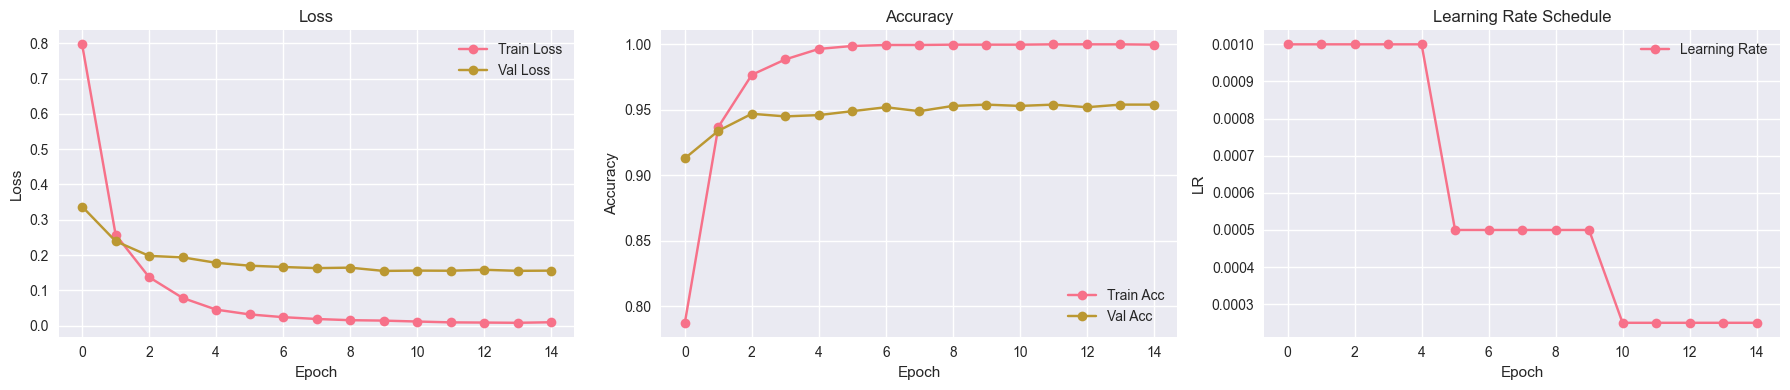

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(train_losses, label="Train Loss", marker="o")
axes[0].plot(val_losses, label="Val Loss", marker="o")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(train_accs, label="Train Acc", marker="o")
axes[1].plot(val_accs, label="Val Acc", marker="o")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(lrs, label="Learning Rate", marker="o")
axes[2].set_title("Learning Rate Schedule")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("LR")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()